## CME FEB 2024

In [18]:
import pandas as pd
import numpy as np

cme_feb_2024 = pd.read_csv("../../data/raw/CME/CME_FEB_2024.csv")
cme_feb_2024 = cme_feb_2024.reset_index(drop = True)
cme_feb_2024["time"] = pd.to_datetime(cme_feb_2024["time"],unit="s") 

In [19]:
cme_feb_2024

,time,open,high,low,close,Volume
0,2023-10-15 22:00:00,94.5850,94.5850,94.5750,94.5800,109
1,2023-10-15 22:01:00,94.5800,94.5800,94.5800,94.5800,3
2,2023-10-15 22:04:00,94.5800,94.5800,94.5800,94.5800,1
3,2023-10-15 22:05:00,94.5800,94.5800,94.5800,94.5800,4
4,2023-10-15 22:06:00,94.5800,94.5800,94.5800,94.5800,1
...,...,...,...,...,...,...
21230,2024-02-29 17:01:00,94.6700,94.6700,94.6700,94.6700,2
21231,2024-02-29 17:06:00,94.6700,94.6700,94.6700,94.6700,10
21232,2024-02-29 17:20:00,94.6725,94.6725,94.6725,94.6725,8
21233,2024-02-29 20:47:00,94.6700,94.6700,94.6700,94.6700,3


## CME MAR 2024

In [20]:
cme_mar_2024 = pd.read_csv("../../data/raw/CME/CME_MAR_2024.csv")
cme_mar_2024 = cme_mar_2024.reset_index(drop = True)
cme_mar_2024["time"] = pd.to_datetime(cme_mar_2024["time"],unit="s") 

In [21]:
cme_mar_2024

,time,open,high,low,close,Volume
0,2023-09-10 22:09:00,94.62,94.62,94.62,94.62,5
1,2023-09-10 22:13:00,94.62,94.62,94.62,94.62,6
2,2023-09-10 22:24:00,94.62,94.62,94.62,94.62,6
3,2023-09-11 00:04:00,94.62,94.62,94.62,94.62,6
4,2023-09-11 04:42:00,94.62,94.62,94.62,94.62,2
...,...,...,...,...,...,...
20103,2024-03-28 17:04:00,94.67,94.67,94.67,94.67,6
20104,2024-03-28 17:38:00,94.67,94.67,94.67,94.67,3
20105,2024-03-28 17:44:00,94.67,94.67,94.67,94.67,8
20106,2024-03-28 17:55:00,94.67,94.67,94.67,94.67,395


## Merge and then calculate probabilities

In [22]:
feb = cme_feb_2024.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")
feb = feb.sort_values("time").set_index("time")

feb = feb.add_suffix("_feb_2024")

mar = cme_mar_2024.copy()
mar["time"] = pd.to_datetime(mar["time"], unit="s")
mar = mar.sort_values("time").set_index("time")

mar = mar.add_suffix("_mar_2024")
feb_aligned = feb.reindex(mar.index, method="ffill")

final_df = pd.concat([mar, feb_aligned], axis=1)
final_df = final_df.reset_index()

In [23]:
final_df

,time,open_mar_2024,high_mar_2024,low_mar_2024,close_mar_2024,Volume_mar_2024,open_feb_2024,high_feb_2024,low_feb_2024,close_feb_2024,Volume_feb_2024
0,2023-09-10 22:09:00,94.62,94.62,94.62,94.62,5,NaN,NaN,NaN,NaN,NaN
1,2023-09-10 22:13:00,94.62,94.62,94.62,94.62,6,NaN,NaN,NaN,NaN,NaN
2,2023-09-10 22:24:00,94.62,94.62,94.62,94.62,6,NaN,NaN,NaN,NaN,NaN
3,2023-09-11 00:04:00,94.62,94.62,94.62,94.62,6,NaN,NaN,NaN,NaN,NaN
4,2023-09-11 04:42:00,94.62,94.62,94.62,94.62,2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
20103,2024-03-28 17:04:00,94.67,94.67,94.67,94.67,6,94.67,94.67,94.67,94.67,1.0
20104,2024-03-28 17:38:00,94.67,94.67,94.67,94.67,3,94.67,94.67,94.67,94.67,1.0
20105,2024-03-28 17:44:00,94.67,94.67,94.67,94.67,8,94.67,94.67,94.67,94.67,1.0
20106,2024-03-28 17:55:00,94.67,94.67,94.67,94.67,395,94.67,94.67,94.67,94.67,1.0


## Calculating Implied Probabilities

In [24]:
meeting_day = 20
days_in_mar = 28

N = meeting_day           
M = days_in_mar - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2024"]
imp_df["effr_avg_mar"] = 100 - final_df["close_mar_2024"]

imp_df["effr_end_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_start_mar"] = imp_df["effr_end_feb"]
imp_df["volume"] = final_df["Volume_mar_2024"]


In [25]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume
0,2023-09-10 22:09:00,NaN,5.38,NaN,NaN,5
1,2023-09-10 22:13:00,NaN,5.38,NaN,NaN,6
2,2023-09-10 22:24:00,NaN,5.38,NaN,NaN,6
3,2023-09-11 00:04:00,NaN,5.38,NaN,NaN,6
4,2023-09-11 04:42:00,NaN,5.38,NaN,NaN,2
...,...,...,...,...,...,...
20103,2024-03-28 17:04:00,5.33,5.33,5.33,5.33,6
20104,2024-03-28 17:38:00,5.33,5.33,5.33,5.33,3
20105,2024-03-28 17:44:00,5.33,5.33,5.33,5.33,8
20106,2024-03-28 17:55:00,5.33,5.33,5.33,5.33,395


In [26]:
imp_df["effr_end_mar"] = (
    imp_df["effr_avg_mar"] - (N / (N + M)) * imp_df["effr_start_mar"]
) / (M / (N + M))

In [27]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume,effr_end_mar
0,2023-09-10 22:09:00,NaN,5.38,NaN,NaN,5,NaN
1,2023-09-10 22:13:00,NaN,5.38,NaN,NaN,6,NaN
2,2023-09-10 22:24:00,NaN,5.38,NaN,NaN,6,NaN
3,2023-09-11 00:04:00,NaN,5.38,NaN,NaN,6,NaN
4,2023-09-11 04:42:00,NaN,5.38,NaN,NaN,2,NaN
...,...,...,...,...,...,...,...
20103,2024-03-28 17:04:00,5.33,5.33,5.33,5.33,6,5.33
20104,2024-03-28 17:38:00,5.33,5.33,5.33,5.33,3,5.33
20105,2024-03-28 17:44:00,5.33,5.33,5.33,5.33,8,5.33
20106,2024-03-28 17:55:00,5.33,5.33,5.33,5.33,395,5.33


In [29]:
imp_df = imp_df.dropna()

In [30]:
imp_df["delta_effr"] = imp_df["effr_end_mar"] - imp_df["effr_start_mar"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [31]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume,effr_end_mar,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
3532,2023-10-15 22:00:00,5.42,5.40,5.42,5.42,6,5.35,-0.07,-0.28,-1.0,0.72,0.0,0.0,0.0,0.28,0.72,0.0,0.0,0.0,0.0
3533,2023-10-15 22:12:00,5.42,5.40,5.42,5.42,3,5.35,-0.07,-0.28,-1.0,0.72,0.0,0.0,0.0,0.28,0.72,0.0,0.0,0.0,0.0
3534,2023-10-15 22:40:00,5.42,5.40,5.42,5.42,3,5.35,-0.07,-0.28,-1.0,0.72,0.0,0.0,0.0,0.28,0.72,0.0,0.0,0.0,0.0
3535,2023-10-15 22:45:00,5.42,5.40,5.42,5.42,4,5.35,-0.07,-0.28,-1.0,0.72,0.0,0.0,0.0,0.28,0.72,0.0,0.0,0.0,0.0
3536,2023-10-15 22:51:00,5.42,5.40,5.42,5.42,3,5.35,-0.07,-0.28,-1.0,0.72,0.0,0.0,0.0,0.28,0.72,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20103,2024-03-28 17:04:00,5.33,5.33,5.33,5.33,6,5.33,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,1.00,0.0,0.0,0.0,0.0
20104,2024-03-28 17:38:00,5.33,5.33,5.33,5.33,3,5.33,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,1.00,0.0,0.0,0.0,0.0
20105,2024-03-28 17:44:00,5.33,5.33,5.33,5.33,8,5.33,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,1.00,0.0,0.0,0.0,0.0
20106,2024-03-28 17:55:00,5.33,5.33,5.33,5.33,395,5.33,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,1.00,0.0,0.0,0.0,0.0


In [32]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

## Filtering Based on Announcement Time

In [33]:
fomc_2024_utc = {
    "January 2024": pd.Timestamp("2024-01-31 19:00:00", tz="UTC"),   
    "March 2024": pd.Timestamp("2024-03-20 18:00:00", tz="UTC"),     
    "May 2024": pd.Timestamp("2024-05-01 18:00:00", tz="UTC"),       
    "June 2024": pd.Timestamp("2024-06-12 18:00:00", tz="UTC"),      
    "July 2024": pd.Timestamp("2024-07-31 18:00:00", tz="UTC"),      
    "September 2024": pd.Timestamp("2024-09-18 18:00:00", tz="UTC"), 
    "November 2024": pd.Timestamp("2024-11-07 19:00:00", tz="UTC"),  
    "December 2024": pd.Timestamp("2024-12-18 19:00:00", tz="UTC"),  
}

In [34]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [35]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2024_utc)

In [36]:
imp_df_fil

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,volume,effr_end_mar,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
3532,2023-10-15 22:00:00+00:00,5.42,5.4000,5.42,5.42,6,5.35000,-0.07000,-0.280,-1.0,0.720,0.0,0.0,0.0,0.280,0.720,0.0,0.0,0.0,0.0
3533,2023-10-15 22:12:00+00:00,5.42,5.4000,5.42,5.42,3,5.35000,-0.07000,-0.280,-1.0,0.720,0.0,0.0,0.0,0.280,0.720,0.0,0.0,0.0,0.0
3534,2023-10-15 22:40:00+00:00,5.42,5.4000,5.42,5.42,3,5.35000,-0.07000,-0.280,-1.0,0.720,0.0,0.0,0.0,0.280,0.720,0.0,0.0,0.0,0.0
3535,2023-10-15 22:45:00+00:00,5.42,5.4000,5.42,5.42,4,5.35000,-0.07000,-0.280,-1.0,0.720,0.0,0.0,0.0,0.280,0.720,0.0,0.0,0.0,0.0
3536,2023-10-15 22:51:00+00:00,5.42,5.4000,5.42,5.42,3,5.35000,-0.07000,-0.280,-1.0,0.720,0.0,0.0,0.0,0.280,0.720,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19799,2024-03-20 17:51:00+00:00,5.33,5.3300,5.33,5.33,4677,5.33000,0.00000,0.000,0.0,0.000,0.0,0.0,0.0,0.000,1.000,0.0,0.0,0.0,0.0
19800,2024-03-20 17:54:00+00:00,5.33,5.3300,5.33,5.33,112,5.33000,0.00000,0.000,0.0,0.000,0.0,0.0,0.0,0.000,1.000,0.0,0.0,0.0,0.0
19801,2024-03-20 17:57:00+00:00,5.33,5.3300,5.33,5.33,396,5.33000,0.00000,0.000,0.0,0.000,0.0,0.0,0.0,0.000,1.000,0.0,0.0,0.0,0.0
19802,2024-03-20 17:59:00+00:00,5.33,5.3275,5.33,5.33,1,5.32125,-0.00875,-0.035,-1.0,0.965,0.0,0.0,0.0,0.035,0.965,0.0,0.0,0.0,0.0


## Export the Data as a CSV

In [37]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_MAR_2024.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)

## Visualization 

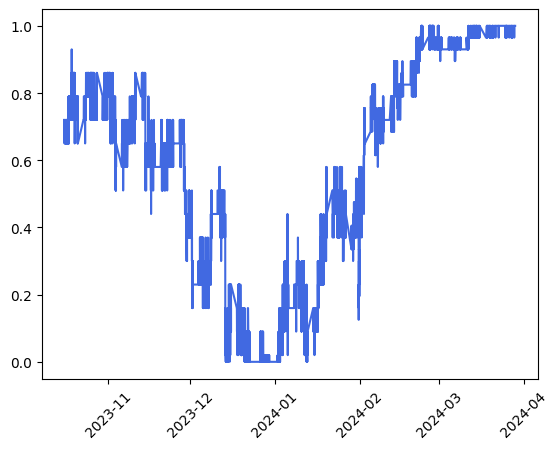

In [38]:
import matplotlib.pyplot as plt

plt.plot(imp_df["time"],imp_df['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()